# Dinosaur and Cinema Films Data Analysis Report

# 1️⃣ Part 1 (Python) - Dinosaur data 🦕

## 📖 Background
You're applying for a summer internship at a national museum for natural history. The museum recently created a database containing all dinosaur records of past field campaigns. Your job is to dive into the fossil records to find some interesting insights, and advise the museum on the quality of the data. 

## 💾 The data

### You have access to a real dataset containing dinosaur records from the Paleobiology Database ([source](https://paleobiodb.org/#/)):


| Column name | Description |
|---|---|
| occurence_no | The original occurrence number from the Paleobiology Database. |
| name | The accepted name of the dinosaur (usually the genus name, or the name of the footprint/egg fossil). |
| diet | The main diet (omnivorous, carnivorous, herbivorous). |
| type | The dinosaur type (small theropod, large theropod, sauropod, ornithopod, ceratopsian, armored dinosaur). |
| length_m | The maximum length, from head to tail, in meters. |
| max_ma | The age in which the first fossil records of the dinosaur where found, in million years. |
| min_ma | The age in which the last fossil records of the dinosaur where found, in million years. |
| region | The current region where the fossil record was found. |
| lng | The longitude where the fossil record was found. |
| lat | The latitude where the fossil record was found. |
| class | The taxonomical class of the dinosaur (Saurischia or Ornithischia). |
| family | The taxonomical family of the dinosaur (if known). |

The data was enriched with data from Wikipedia.

In [34]:
# Import the pandas and numpy packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

# Load the data
dinosaurs = pd.read_csv('data/dinosaurs.csv')

In [3]:
# Preview the dataframe
dinosaurs

,occurrence_no,name,diet,type,length_m,max_ma,min_ma,region,lng,lat,class,family
0,130294,Protarchaeopteryx,omnivorous,small theropod,2.0,130.0,122.46,Liaoning,120.733330,41.799999,Saurischia,Archaeopterygidae
1,130295,Caudipteryx,omnivorous,small theropod,1.0,130.0,122.46,Liaoning,120.733330,41.799999,Saurischia,Caudipterygidae
2,139242,Gorgosaurus,carnivorous,large theropod,8.6,83.5,70.60,Alberta,-111.528732,50.740726,Saurischia,Tyrannosauridae
3,139250,Gorgosaurus,carnivorous,large theropod,8.6,83.5,70.60,Alberta,-111.549347,50.737015,Saurischia,Tyrannosauridae
4,139252,Gorgosaurus,carnivorous,large theropod,8.6,83.5,70.60,Alberta,-111.564636,50.723866,Saurischia,Tyrannosauridae
...,...,...,...,...,...,...,...,...,...,...,...,...
4946,1360627,Isaberrysaura,NaN,NaN,NaN,171.6,168.40,Neuquén,-70.263290,-39.205288,Ornithischia,NaN
4947,1363632,Stegosaurus,herbivorous,armored dinosaur,9.0,157.3,152.10,Wyoming,-107.816666,44.650002,Ornithischia,Stegosauridae
4948,1363633,Othnielosaurus,NaN,NaN,NaN,157.3,152.10,Wyoming,-107.816666,44.650002,Ornithischia,NaN
4949,1364695,Iguanodon,herbivorous,ornithopod,10.0,145.0,139.80,Niedersachsen,9.959357,52.341167,Ornithischia,NaN


## 💪 Challenge I
Help your colleagues at the museum to gain insights on the fossil record data. Include:


1. How many different dinosaur names are present in the data?
2. Which was the largest dinosaur? What about missing data in the dataset?
3. What dinosaur type has the most occurrences in this dataset? Create a visualization (table, bar chart, or equivalent) to display the number of dinosaurs per type. Use the AI assistant to tweak your visualization (colors, labels, title...).
4. Did dinosaurs get bigger over time? Show the relation between the dinosaur length and their age to illustrate this.
5. Use the AI assistant to create an interactive map showing each record. 
6. Any other insights you found during your analysis?

In [58]:
# Count the number of unique dinosaur names in the 'name' column of the dataframe
countName = len(dinosaurs['name'].unique())

# Display the count of unique dinosaur names with a descriptive message
from IPython.display import display, Markdown

display(Markdown(f"### 🦕 Number of Unique Dinosaur Names from Dataset: {countName}"))

### 🦕 Number of Unique Dinosaur Names from Dataset: 1042

In [61]:
# Find the maximum value in the 'length_m' column, which represents the length of the dinosaurs in meters
largestLength = dinosaurs['length_m'].max()

# Filter the dataframe to find the dinosaur(s) with the maximum length
# This will return a dataframe containing the name(s) and length(s) of the largest dinosaur(s)
largestDino = dinosaurs[dinosaurs['length_m'] == largestLength][['name', 'length_m']]

# Extract the unique dinosaur name(s) from the largestDino dataframe
uniqueLargestDino = list(largestDino['name'].unique())

# Display the names of the largest dinosaurs
from IPython.display import display, Markdown

display(Markdown(f"### 🦖 The largest dinosaurs (with length {largestLength} m) from dataset are: {', '.join(uniqueLargestDino)}"))

### 🦖 The largest dinosaurs (with length 35.0 m) from dataset are: Supersaurus, Argentinosaurus

## Below is the image of Argentinosaurus (source: ThoughtCo)  
![Argentinosaurus](argentinosaurus.jpg)

## Below is the image of Argentinosaurus (source: earth.com)  
![Supersaurus](supersaurus.jpg)

In [17]:
# Check for missing data in the dinosaurs dataframe
missing_data = dinosaurs.isnull().sum()

# Display the missing data information with a descriptive message
from IPython.display import display, Markdown

display(Markdown("### Missing Data in Dinosaurs Dataset"))
display(missing_data)

### Missing Data in Dinosaurs Dataset

occurrence_no       0
name                0
diet             1355
type             1355
length_m         1383
max_ma              0
min_ma              0
region             42
lng                 0
lat                 0
class               0
family           1457
dtype: int64

## Number of Dinosaurs per Type

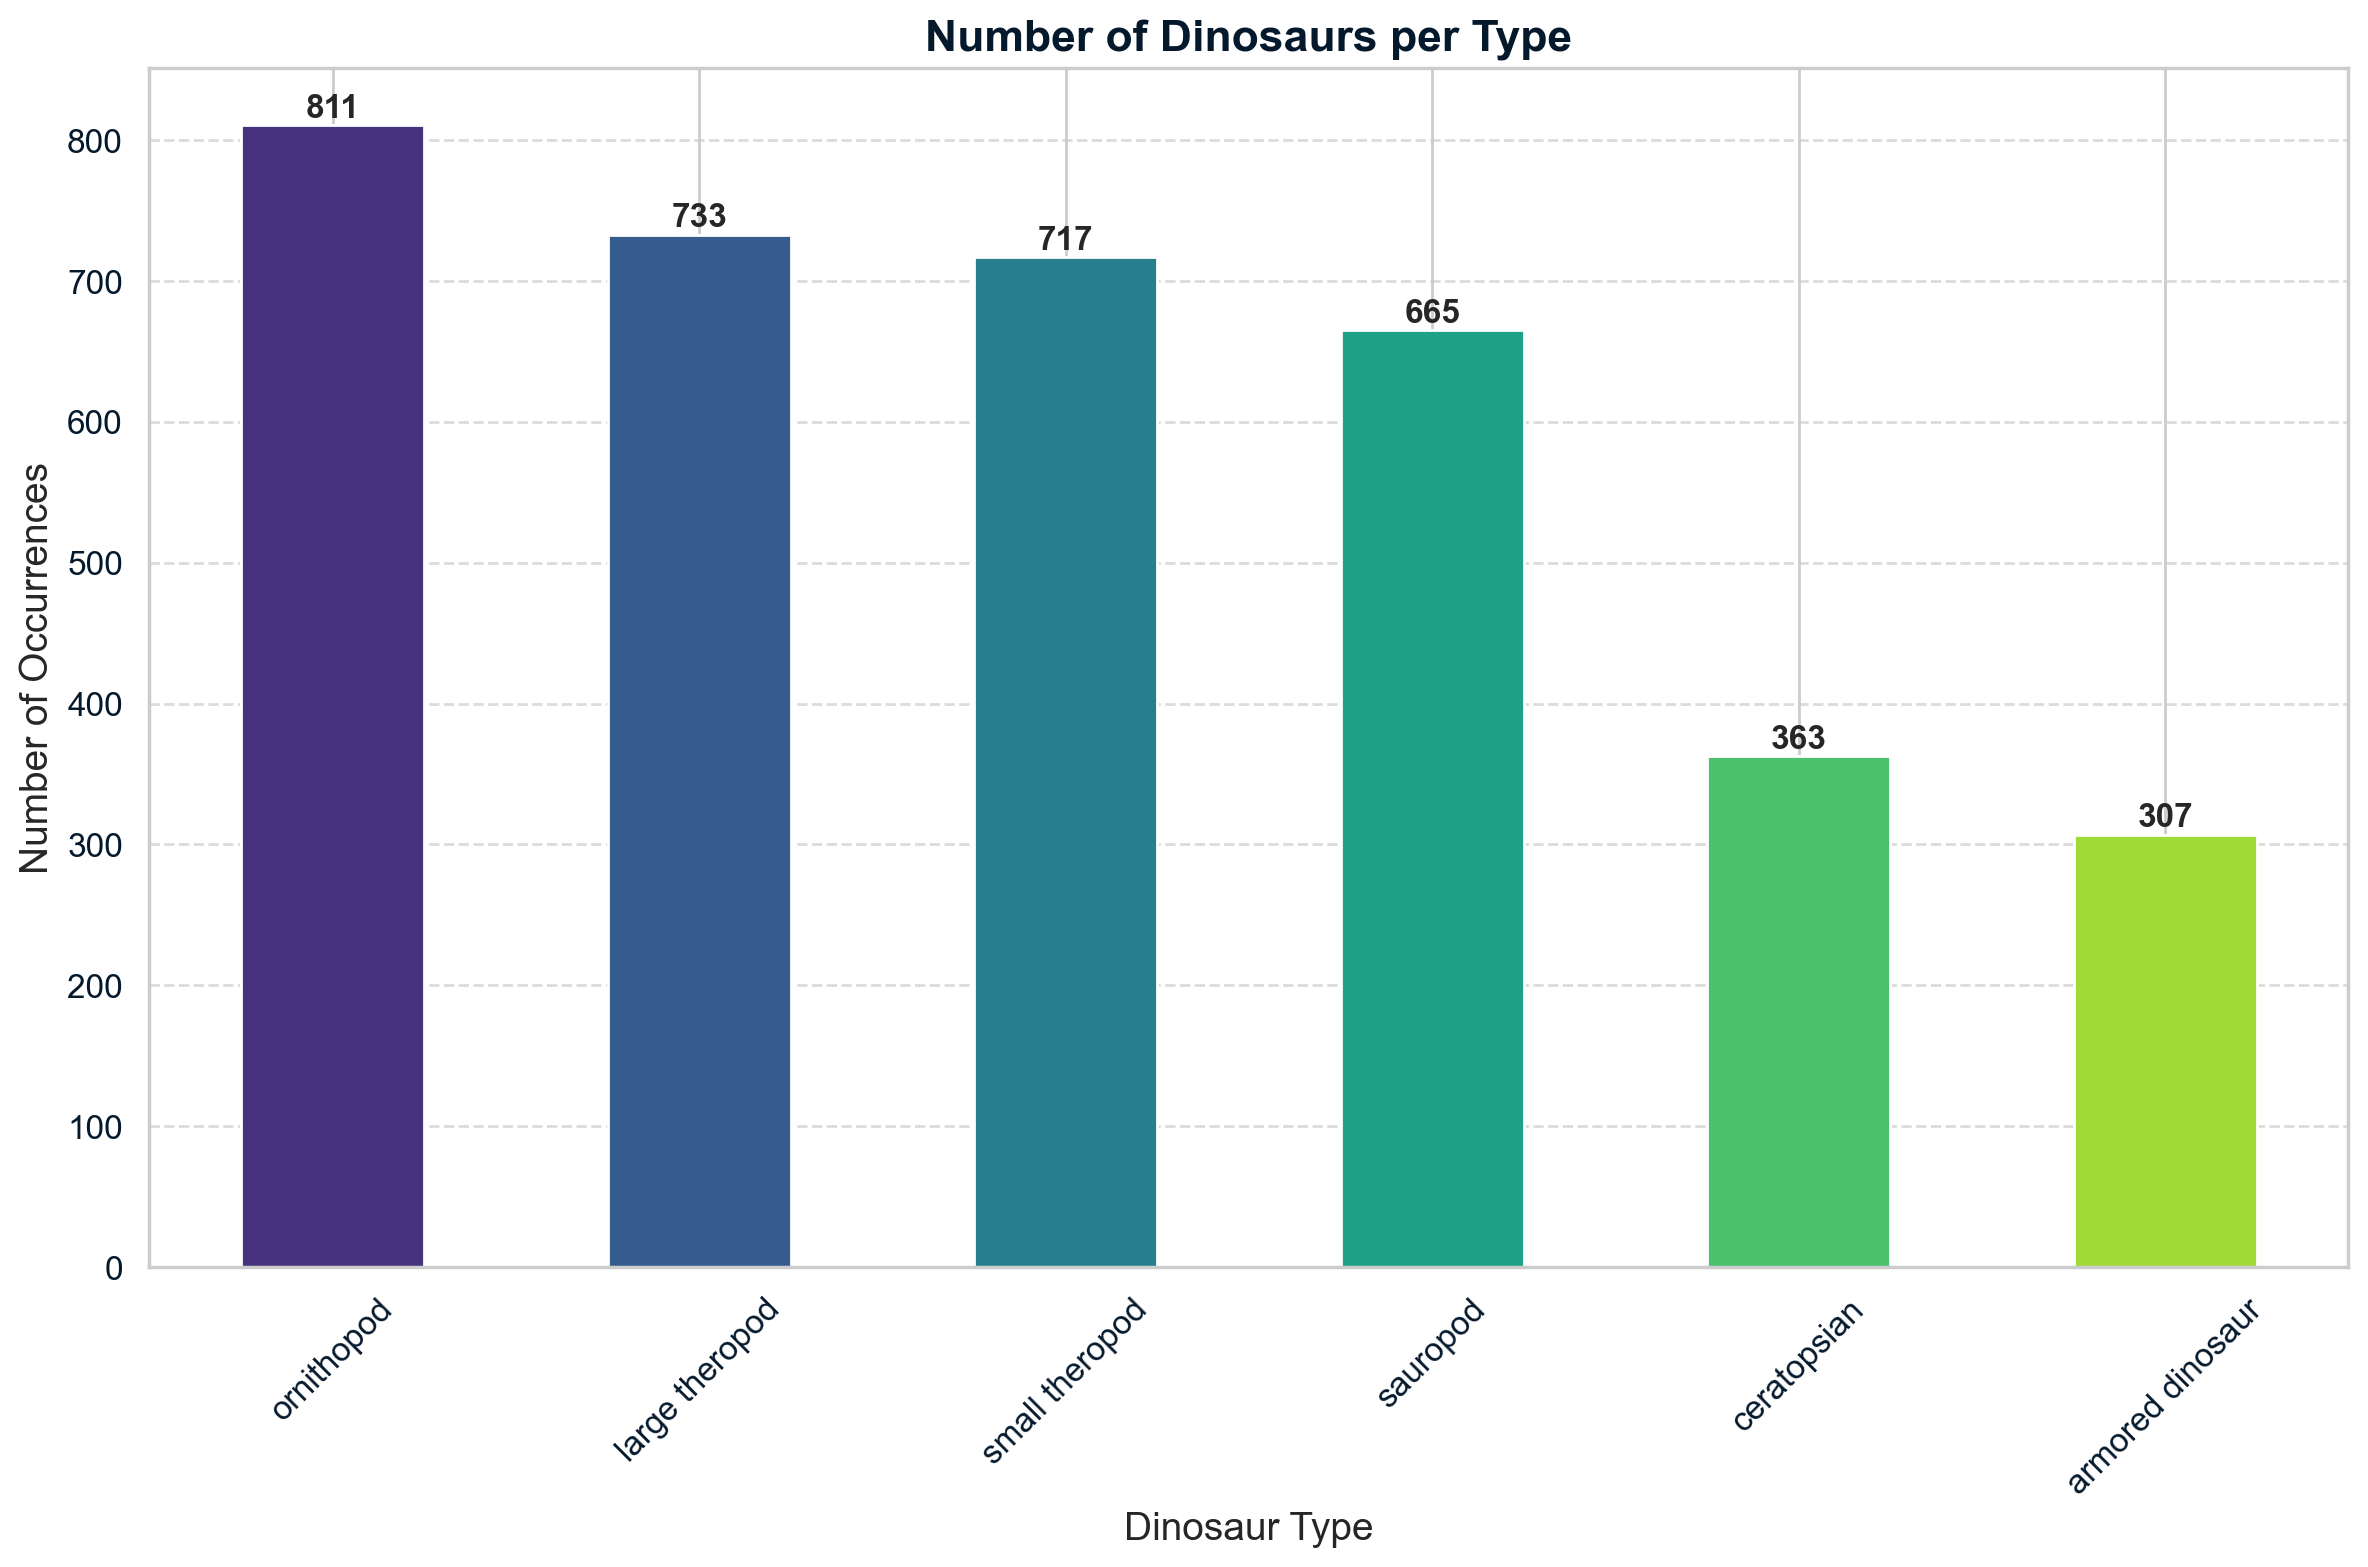

In [23]:
# Count occurrences of each type
type_counts = dinosaurs['type'].value_counts()

# Set the style and color palette
sns.set(style="whitegrid")
palette = sns.color_palette("viridis", len(type_counts))

# Create bar chart
plt.figure(figsize=(12, 8))
type_counts.plot(kind='bar', color=palette)
plt.title('Number of Dinosaurs per Type', fontsize=16, fontweight='bold')
plt.xlabel('Dinosaur Type', fontsize=14)
plt.ylabel('Number of Occurrences', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add value labels on top of the bars
for i, count in enumerate(type_counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

Here are the key takeaways from the bar graph above:
- Armored Dinosaurs: The category with the highest number of occurrences is “armored”, with 811 instances.
- Large Theropods: The second most common type is “large theropod”, with 733 occurrences.
- Small Theropods: Following closely, “small theropod” appears 717 times.
- Sauropods: The “sauropod” category has 665 occurrences.
- Ornithopods: “Ornithopod” is less frequent, with 363 instances.
- Large Ornithischians: The least common type is “large ornithischian”, with only 307 occurrences.

## Dinosaur Length vs. Age Graph

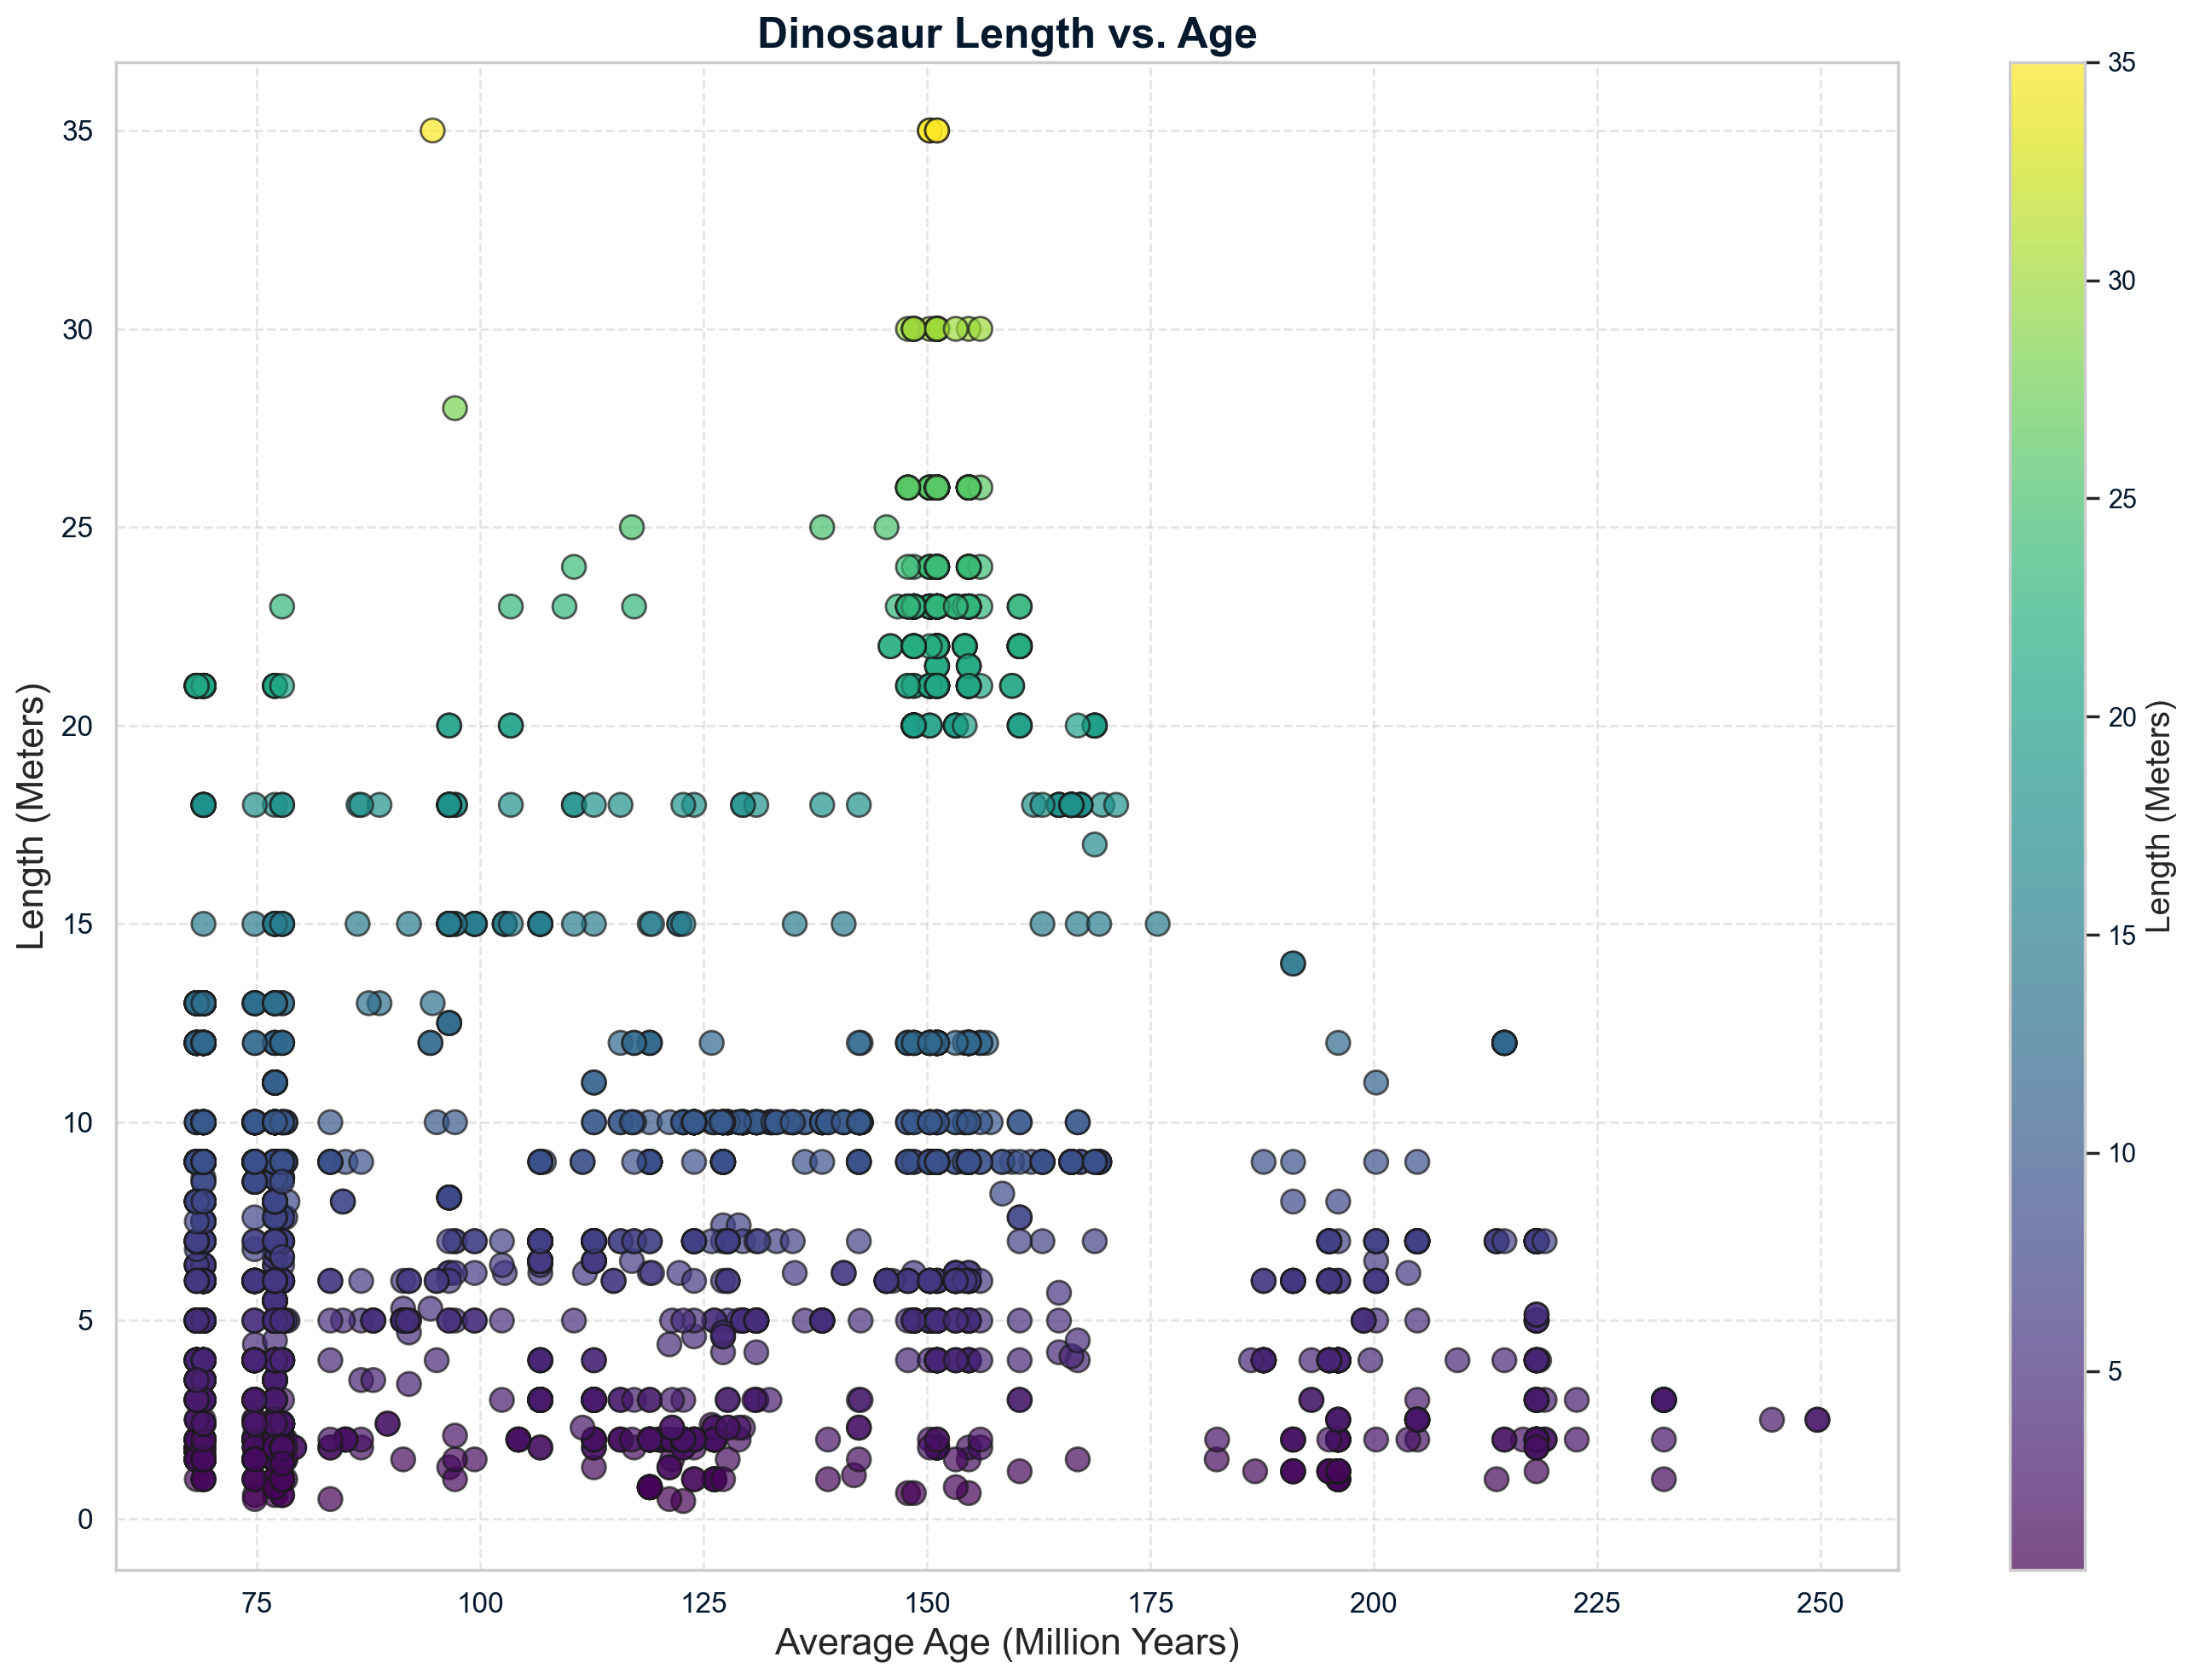

In [25]:
# Calculate the average age in million years
dinosaurs['average_age_ma'] = (dinosaurs['max_ma'] + dinosaurs['min_ma']) / 2

# Scatter plot of length versus average age with enhanced visualization
plt.figure(figsize=(14, 10))

# Use a colormap for better visual distinction
scatter = plt.scatter(dinosaurs['average_age_ma'], dinosaurs['length_m'], 
                      c=dinosaurs['length_m'], cmap='viridis', edgecolor='k', s=100, alpha=0.7)

# Add color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Length (Meters)', fontsize=14)

# Add titles and labels with enhanced font properties
plt.title('Dinosaur Length vs. Age', fontsize=18, fontweight='bold')
plt.xlabel('Average Age (Million Years)', fontsize=16)
plt.ylabel('Length (Meters)', fontsize=16)

# Customize grid
plt.grid(True, linestyle='--', alpha=0.5)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show plot
plt.tight_layout()
plt.show()

Based on the scatter plot above, we can analyze the relationship between dinosaur length and their age in more detail:

### Observations:

1. **Length Distribution by Age**:
   - **Younger Dinosaurs (approximately 75 to 125 million years)**: These dinosaurs show a wide range of lengths, from very small (under 5 meters) to moderately large (up to 15 meters). However, there is a smaller cluster of dinosaurs in the 20 to 25 meter range.
   - **Middle Age Dinosaurs (approximately 125 to 200 million years)**: This period shows an increase in the presence of larger dinosaurs, with lengths reaching up to 30 meters or more. There is a noticeable cluster of dinosaurs in the 20 to 25 meter range.
   - **Older Dinosaurs (above 200 million years)**: The dataset shows fewer dinosaur records in this age range, but the available data indicates the presence of smaller dinosaurs, generally under 10 meters. This suggests that earlier in the dinosaur evolutionary timeline, the sizes were relatively smaller compared to the middle age period.

2. **Color Coding**:
   - The color coding on the scatter plot represents the length of the dinosaurs, with darker colors indicating smaller lengths and lighter colors indicating larger lengths. This helps visualize that larger dinosaurs are more frequently found in the middle to older age ranges.

### Trend Analysis:

- **Increase in Size Over Time**:
  - The scatter plot indicates that as time progressed (from older dinosaurs to younger dinosaurs), the maximum size that dinosaurs could attain increased, particularly in the period around 100 to 150 million years ago.
  - This indicates that the presence of very large dinosaurs becomes more common in the middle age range (125 to 200 million years ago). In the old age period (over 200 million years ago), the sizes tend to be smaller, indicating that the earliest dinosaurs were not as large as those that evolved later.

- **Diversity in Sizes**:
  - For younger dinosaurs and middle age dinosaurs, there is a diversity of dinosaur sizes. However, the trend suggests that the largest sizes were predominantly achieved during the middle age period.

### Summary:

The scatter plot illustrates that dinosaurs get bigger over time. This indicates that evolutionary pressures allowed for both large and small dinosaurs to coexist, and that the overall size increase did not eliminate the presence of smaller species.

## Interactive Map for Dinosaur Fossils

In [46]:
# Ensure the 'lng' and 'lat' columns do not have missing values
dinosaurs = dinosaurs.dropna(subset=['lng', 'lat'])

# Create a 'Coordinates' column in the 'dinosaurs' DataFrame using the 'lng' and 'lat' columns
dinosaurs['Coordinates'] = dinosaurs.apply(lambda row: Point(row['lng'], row['lat']), axis=1)

# Convert the 'dinosaurs' DataFrame to a GeoDataFrame using the 'Coordinates' column for geometry
gdf = gpd.GeoDataFrame(dinosaurs, geometry='Coordinates')

# Set the coordinate reference system (CRS) to WGS84 (EPSG:4326)
gdf.set_crs(epsg=4326, inplace=True)

# Display an interactive map of the GeoDataFrame
gdf.explore()

## Additional Insight: Top 5 Regions by Average Dinosaur Length

The region with the highest average length is Santarem with an average length of 23.00 meters.


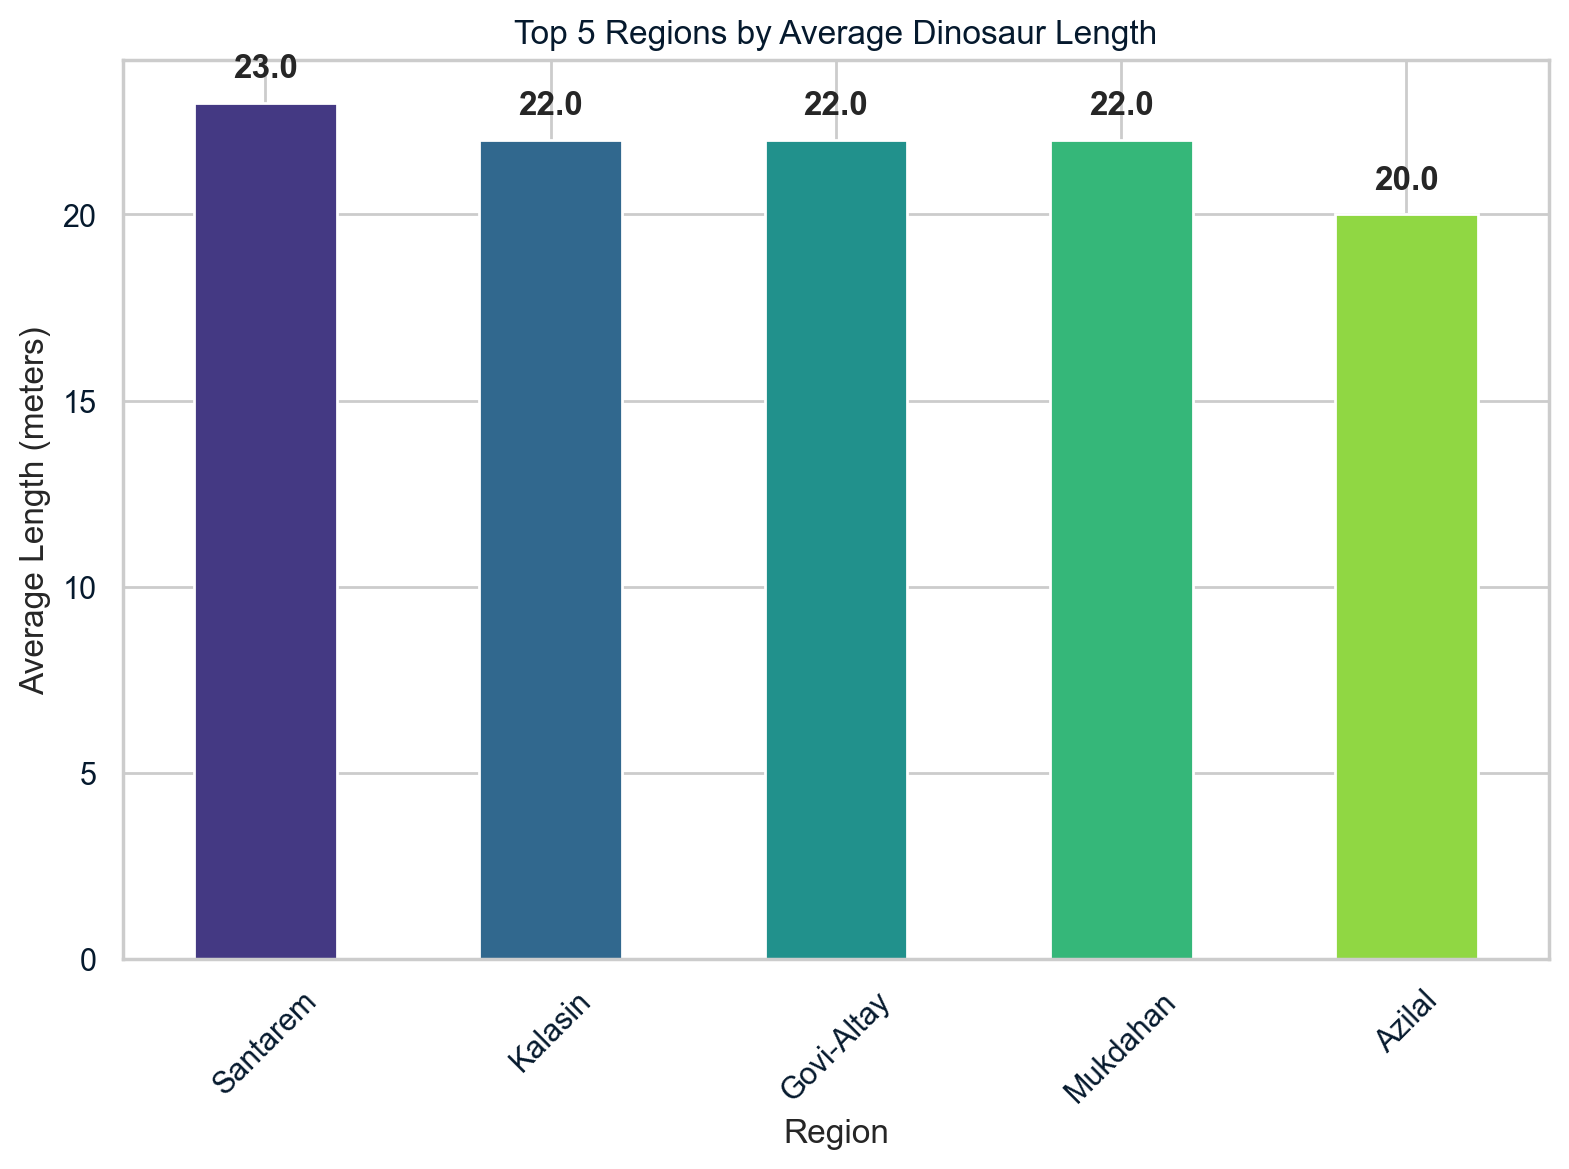

In [40]:
# Group by region and calculate average length
avg_length_by_region = dinosaurs.groupby('region')['length_m'].mean()

# Sort by average length in descending order
avg_length_by_region = avg_length_by_region.sort_values(ascending=False)

# Find the region with the highest average length
max_avg_length_region = avg_length_by_region.idxmax()
max_avg_length = avg_length_by_region.max()

print(f"The region with the highest average length is {max_avg_length_region} with an average length of {max_avg_length:.2f} meters.")

# Select the top 5 regions
top_5_regions = avg_length_by_region.head(5)

# Set the style and color palette
sns.set(style="whitegrid")
palette = sns.color_palette("viridis", len(top_5_regions))

# Create a bar chart for the top 5 regions
plt.figure(figsize=(8, 6))
top_5_regions.plot(kind='bar', color=palette)
plt.xlabel('Region')
plt.ylabel('Average Length (meters)')
plt.title('Top 5 Regions by Average Dinosaur Length')
plt.xticks(rotation=45)
plt.tight_layout()

# Add value labels on top of the bars
for i, count in enumerate(top_5_regions):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

## Additional Insight: Top 3 Diets by Average Dinosaur Length

The diet with the highest average length is herbivorous with an average length of 10.29 meters.
The diet with the lowest average length is omnivorous with an average length of 4.21 meters.


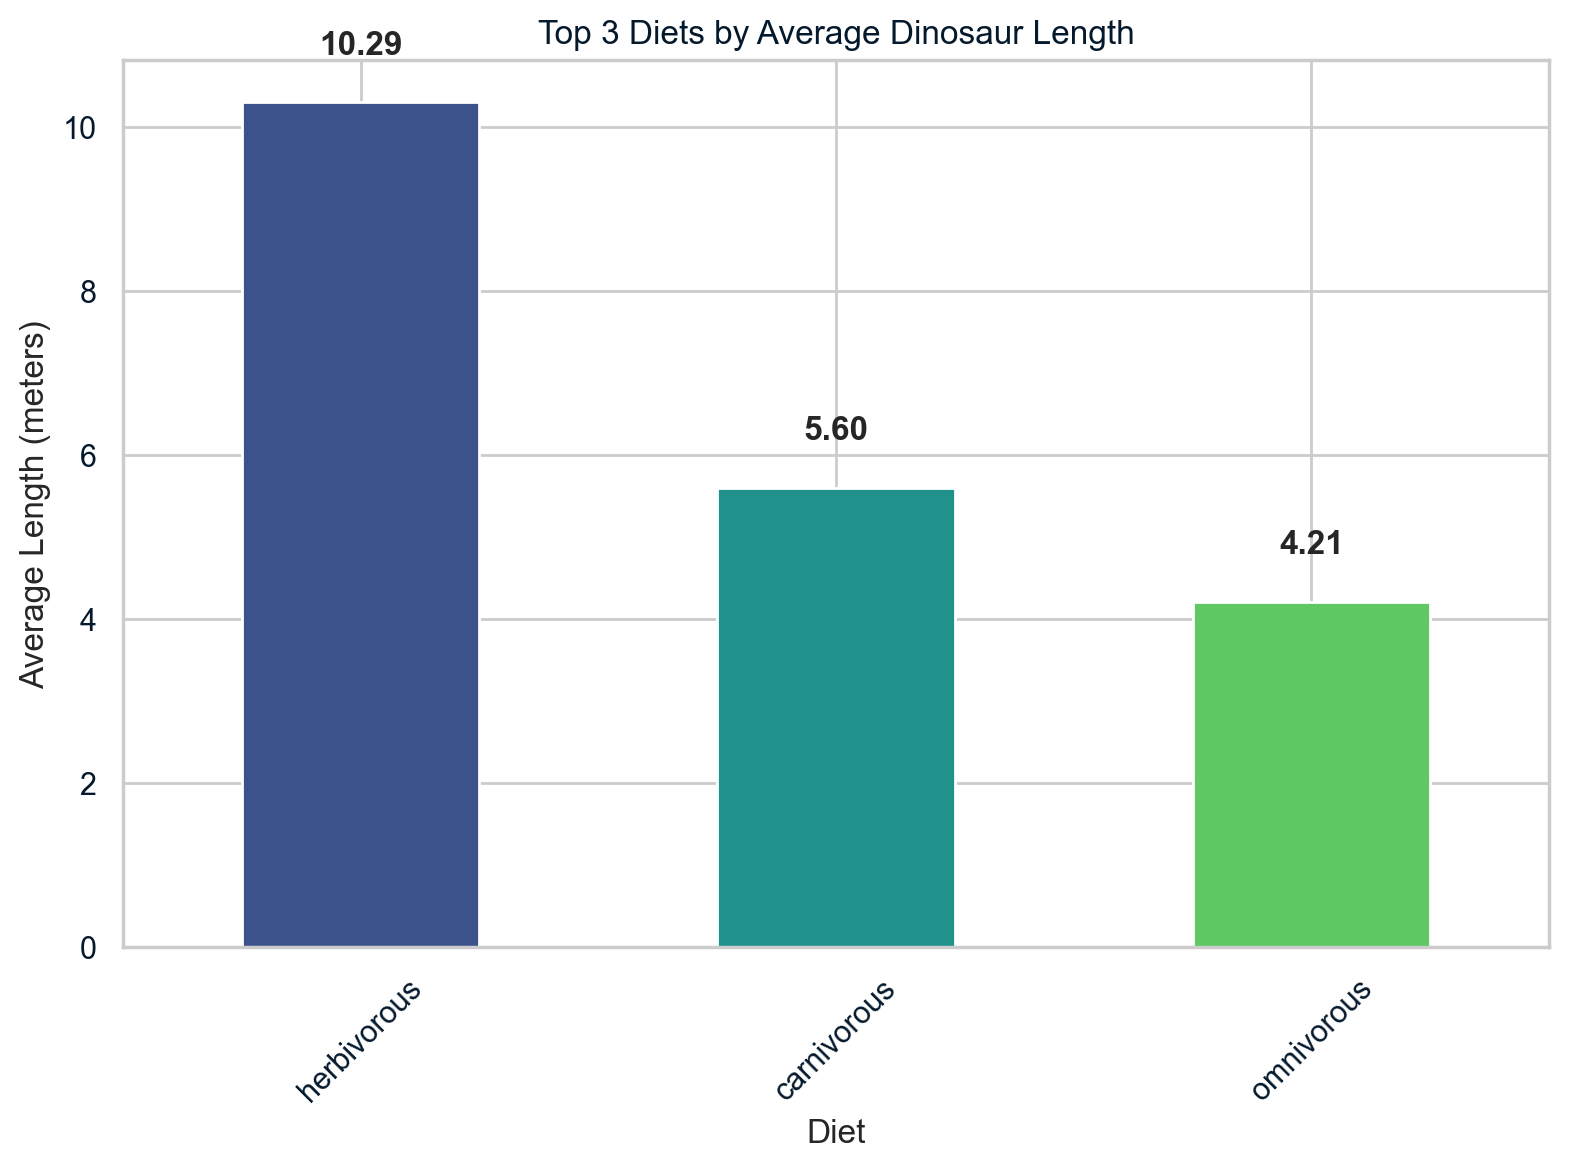

In [65]:
# Group by diet and calculate average length
avg_length_by_diet = dinosaurs.groupby('diet')['length_m'].mean()

# Sort by average length in descending order
avg_length_by_diet = avg_length_by_diet.sort_values(ascending=False)

# Find the diet with the highest average length
max_avg_length_diet = avg_length_by_diet.idxmax()
max_avg_length = avg_length_by_diet.max()

# Find the diet with the lowest average length
min_avg_length_diet = avg_length_by_diet.idxmin()
min_avg_length = avg_length_by_diet.min()

print(f"The diet with the highest average length is {max_avg_length_diet} with an average length of {max_avg_length:.2f} meters.")
print(f"The diet with the lowest average length is {min_avg_length_diet} with an average length of {min_avg_length:.2f} meters.")

# Set the style and color palette
sns.set(style="whitegrid")
palette = sns.color_palette("viridis", len(avg_length_by_diet))

# Create a bar chart for the top 3 diets
plt.figure(figsize=(8, 6))
avg_length_by_diet.plot(kind='bar', color=palette)
plt.xlabel('Diet')
plt.ylabel('Average Length (meters)')
plt.title('Top 3 Diets by Average Dinosaur Length')
plt.xticks(rotation=45)
plt.tight_layout()

# Add value labels on top of the bars
for i, count in enumerate(avg_length_by_diet):
    plt.text(i, count + 0.5, f"{count:.2f}", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

# 2️⃣ Part 2 (SQL) - Understanding movie data 🎥 

## 📖 Background
You have just been hired by a large movie studio to perform data analysis. Your manager, an executive at the company, wants to make new movies that "recapture the magic of old Hollywood." So you've decided to look at the most successful films that came out before Titanic in 1997 to identify patterns and help generate ideas that could turn into future successful films.

## 💾 The data

### You have access to the following table, _**cinema.films**_:

| Column name | Description |
|---|---|
| id | Unique movie identifier. |
| title | The title of the movie. |
| release_year | The year the movie was released to the public. |
| country | The country in which the movie was released. |
| duration | The runtime of the movie, in minutes. |
| language | The original language the movie was produced in. |
| certification | The [rating](https://simple.wikipedia.org/wiki/Motion_Picture_Association_film_rating_system) the movie was given based on their suitability for audiences. |
| gross | The revenue the movie generated at the box office, in USD. |
| budget | The available budget the production had for producing the movie, in USD. |

You can click the "Browse tables" button in the upper right-hand corner of the SQL cell below to view the available tables. They will show on the left of the notebook.

The data was sourced from [IMDb](https://www.imdb.com/).

In [16]:
SELECT * 
FROM cinema.films
LIMIT 10

,id,title,release_year,country,duration,language,certification,gross,budget
0,1,Intolerance: Love's Struggle Throughout the Ages,1916,USA,123,,Not Rated,NaN,385907.0
1,2,Over the Hill to the Poorhouse,1920,USA,110,,,3000000.0,100000.0
2,3,The Big Parade,1925,USA,151,,Not Rated,NaN,245000.0
3,4,Metropolis,1927,Germany,145,German,Not Rated,26435.0,6000000.0
4,5,Pandora's Box,1929,Germany,110,German,Not Rated,9950.0,NaN
5,6,The Broadway Melody,1929,USA,100,English,Passed,2808000.0,379000.0
6,7,Hell's Angels,1930,USA,96,English,Passed,NaN,3950000.0
7,8,A Farewell to Arms,1932,USA,79,English,Unrated,NaN,800000.0
8,9,42nd Street,1933,USA,89,English,Unrated,2300000.0,439000.0
9,10,She Done Him Wrong,1933,USA,66,English,Approved,NaN,200000.0


## 💪 Challenge II
Help your team leader understand the data that's available in the _cinema.films_ dataset. Include:

1. How many movies are present in the database?
2. There seems to be a lot of missing data in the gross and budget columns. How many rows have missing data? What would you recommend your manager to do with these rows?
3. How many different certifications or ratings are present in the database?
4. What are the top five countries in terms of number of movies produced?
5. What is the average duration of English versus French movies? (Don't forget you can use the AI assistant!)
6. Any other insights you found during your analysis? 

## How many movies are present in the database?

In [47]:
SELECT COUNT(*) AS total_movies
FROM cinema.films;

,total_movies
0,4968


There is a total of 4968 movies.

## There seems to be a lot of missing data in the gross and budget columns. How many rows have missing data? What would you recommend your manager to do with these rows?

In [48]:
SELECT COUNT(*) AS missing_data_count
FROM cinema.films
WHERE gross IS NULL OR budget IS NULL;

,missing_data_count
0,1076


There is a total of 1076 missing data in the gross and budget columns.

Actions for missing data:
- Exclude them from financial analysis.
- Impute missing values based on similar movies or industry averages.
- Investigate further to understand why the data is missing and address the root cause.

## How many different certifications or ratings are present in the database?

In [49]:
SELECT COUNT(DISTINCT certification) AS unique_certifications
FROM cinema.films;

,unique_certifications
0,13


There is a total of 13 unique certifications present in the database.

## What are the top five countries in terms of number of movies produced?

In [50]:
SELECT country, COUNT(*) AS movie_count
FROM cinema.films
GROUP BY country
ORDER BY movie_count DESC
LIMIT 5;

,country,movie_count
0,USA,3750
1,UK,443
2,France,153
3,Canada,123
4,Germany,97


The top five countries are USA, UK, France, Canada, and Germany.

## What is the average duration of English versus French movies? (Don't forget you can use the AI assistant!)

In [51]:
SELECT
    language,
    AVG(duration) AS average_duration
FROM
    cinema.films
WHERE
    language IN ('English', 'French')
GROUP BY
    language;

,language,average_duration
0,French,104.666667
1,English,107.636541


## Additional Insights: Trends in movie production over the years

In [53]:
SELECT 
    release_year,
    COUNT(*) AS movie_count
FROM 
    cinema.films
GROUP BY 
    release_year
ORDER BY 
    release_year;

,release_year,movie_count
0,1916.0,1
1,1920.0,1
2,1925.0,1
3,1927.0,1
4,1929.0,2
...,...,...
87,2013.0,236
88,2014.0,252
89,2015.0,226
90,2016.0,106


The result of this query shows a **consistent rise** in the number of movies released annually.

## Additional Insights: Correlation between budget and gross revenue

In [54]:
SELECT 
    CORR(budget, gross) AS budget_gross_correlation
FROM 
    cinema.films
WHERE 
    budget IS NOT NULL AND gross IS NOT NULL;

,budget_gross_correlation
0,0.102989


From the result, we can infer that a correlation coefficient of 0.1029892177 suggests a **weak positive** correlation between gross and budget. This means that there is a slight tendency for movies with higher budgets to generate higher gross revenue.

## Additional Insights: Comparison of certification distributions across different countries or languages

In [57]:
SELECT 
    country,
    language,
    certification,
    COUNT(*) AS movie_count
FROM 
    cinema.films
WHERE 
    country <> '' 
    AND language <> '' 
    AND certification <> ''
GROUP BY 
    country, language, certification
ORDER BY 
    country, language, certification;

,country,language,certification,movie_count
0,Afghanistan,Dari,PG-13,1
1,Argentina,Spanish,R,3
2,Argentina,Spanish,Unrated,1
3,Aruba,English,R,1
4,Australia,Aboriginal,PG,1
...,...,...,...,...
221,USA,Spanish,R,4
222,USA,Vietnamese,R,1
223,West Germany,English,PG,1
224,West Germany,German,M,1
